In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import importlib
import source

In [48]:
importlib.reload(source)

<module 'source' from 'c:\\Users\\HP\\Documents\\Keng\\Projects\\MyProject\\RealProject\\something\\source.py'>

In [49]:
from source import PriceSimulator, GreeksEngine, HedgingBot

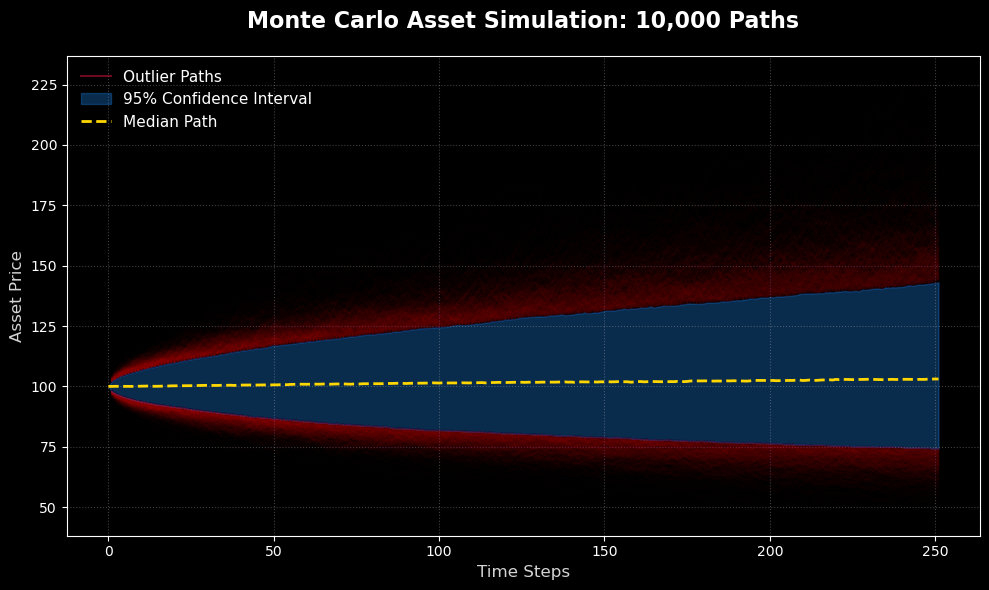

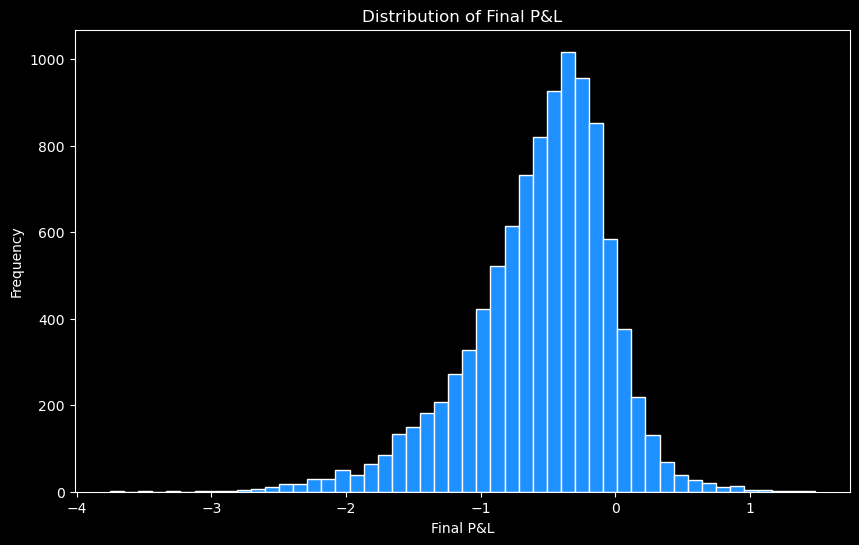

In [50]:
T = 1
n = 252
m = 10_000
r = 0.03
fee_rate = 0.001

sim = PriceSimulator(100, 0.05, 0.2, T, n, m, "GBM") # mu is the real-world drift (P measure), not the risk-free rate (Q measure)
paths = sim.simulate()

greek = GreeksEngine("Call", 110, r, 0.2, 1)
premium = greek.price(100, 0)

t = np.linspace(0, T, n)
all_deltas = greek.compute_all_deltas(paths, t)
delta_diff = all_deltas[:, 1:] - all_deltas[:, :-1]
# prepend initial position change (from 0 to delta_0)
initial_diff = all_deltas[:, 0:1] # shape (m, 1)
delta_diff = np.hstack([initial_diff, delta_diff]) # shape (m, n)
cash_changes = -delta_diff * paths
cost = fee_rate * np.abs(delta_diff) * paths
cash_changes -= cost
time_remaining = T - t
total_cash = premium * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
payoff = np.maximum(paths[:, -1] - greek.K, 0)
final_PnL = total_cash + all_deltas[:, -1] * paths[:, -1] - payoff

VaR_95 = -np.percentile(final_PnL, 5)
CVaR_95 = -final_PnL[final_PnL < -VaR_95].mean()
adjusted_premium = premium + CVaR_95

median_path = np.median(paths, axis=0)
upper_95 = np.percentile(paths, 95, axis=0)
lower_5 = np.percentile(paths, 5, axis=0)
time_steps = np.arange(paths.shape[1])

outside_mask = (paths > upper_95) | (paths < lower_5)
outlier_rows = np.any(outside_mask, axis=1)
outlier_paths = np.where(outside_mask, paths, np.nan)[outlier_rows]

# Plotting paths
plt.figure(figsize=(10, 6))
plt.plot([], [], color='crimson', alpha=0.5, label='Outlier Paths')
plt.plot(outlier_paths.T, color='crimson', alpha=0.01)
plt.fill_between(time_steps, lower_5, upper_95, color='dodgerblue', alpha=0.3, label="95% Confidence Interval")

plt.plot(time_steps, median_path, color="gold", linewidth=2, label="Median Path", linestyle="--")

plt.title(f"Monte Carlo Asset Simulation: {m:,} Paths", fontsize=16, fontweight='bold', pad=20, color='white')

plt.xlabel("Time Steps", fontsize=12, color="lightgray")
plt.ylabel("Asset Price", fontsize=12, color="lightgray")

plt.grid(True, linestyle=":", alpha=0.3, color="lightgray" )
plt.legend(loc="upper left", frameon=False, fontsize=11)
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))
plt.hist(final_PnL, color="dodgerblue", bins=50, edgecolor="white")
plt.xlabel("Final P&L")
plt.ylabel("Frequency")
plt.title("Distribution of Final P&L")
plt.show()

In [51]:
print("-" * 40)
print(f"final P&L mean: {final_PnL.mean()}")
print(f"final P&L SD: {final_PnL.std()}")
print(f"VaR 95%: {VaR_95}\nCVaR 95% = {CVaR_95}")
print(f"BS premium: {premium:.4f}\nCVaR-adjusted premium: {adjusted_premium:.4f}")
print("-" * 40)

----------------------------------------
final P&L mean: -0.5611989755878435
final P&L SD: 0.5250826716070979
VaR 95%: 1.5493446019084083
CVaR 95% = 1.911028547072353
BS premium: 5.2934
CVaR-adjusted premium: 7.2044
----------------------------------------


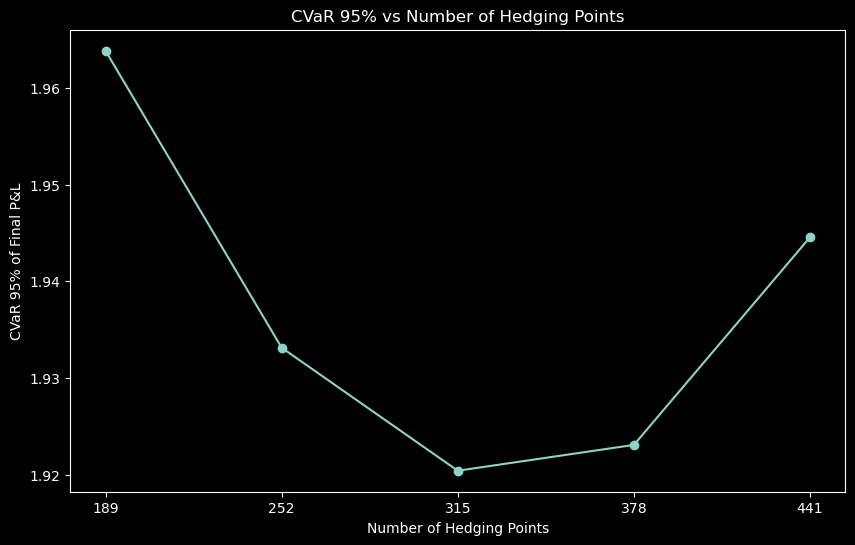

In [52]:
T = 1
m = 10_000
r = 0.03
fee_rate = 0.001

n_items = [189, 252, 315, 378, 441]
CVaR_95_list = []

for n in n_items:
    sim = PriceSimulator(100, 0.05, 0.2, T, n, 10_000, "GBM")
    paths = sim.simulate()

    greek = GreeksEngine("Call", 110, r, 0.2, 1)
    premium = greek.price(100, 0)

    t = np.linspace(0, T, n)
    all_deltas = greek.compute_all_deltas(paths, t)
    delta_diff = all_deltas[:, 1:] - all_deltas[:, :-1]
    # prepend initial position change (from 0 to delta_0)
    initial_diff = all_deltas[:, 0:1] # shape (m, 1)
    delta_diff = np.hstack([initial_diff, delta_diff]) # shape (m, n)
    cash_changes = -delta_diff * paths
    cost = fee_rate * np.abs(delta_diff) * paths
    cash_changes -= cost
    time_remaining = T - t
    total_cash = premium * np.exp(r * T) + (cash_changes * np.exp(r * time_remaining)).sum(axis=1)
    payoff = np.maximum(paths[:, -1] - greek.K, 0)
    final_PnL = total_cash + all_deltas[:, -1] * paths[:, -1] - payoff

    VaR_95 = -np.percentile(final_PnL, 5)
    CVaR_95 = -final_PnL[final_PnL < -VaR_95].mean()

    CVaR_95_list.append(CVaR_95)

plt.figure(figsize=(10, 6))
plt.plot(range(len(n_items)), CVaR_95_list, marker='o')
plt.xticks(range(len(n_items)), n_items)
plt.xlabel("Number of Hedging Points")
plt.ylabel("CVaR 95% of Final P&L")
plt.title("CVaR 95% vs Number of Hedging Points")
plt.show()